# 25. '성공' 정의 민감도 분석 — 다양한 파생변수 적용

`성공 = 고매출 & 장기영업`은 **하나의 값 선택**일 뿐이다. 여러 파생변수로 **7가지 성공 정의**를 만들어
각 정의가 (a) 입지 피처로 **예측 가능한가**(AUC), (b) 창업기상도 API 종합과 **일치하는가**(Cohen κ) 비교한다.

- 모든 타깃은 **(업종·분기) 내 백분위**로 정의 → 시간추세·업종 스케일 제거(전역 임계값은 시간추세에 오염됨).
- 검증: **GroupKFold by (gu,biz)** (정체성 누설 차단).

In [1]:
from pathlib import Path
import pandas as pd, numpy as np, glob, os
import matplotlib, matplotlib.pyplot as plt, platform
matplotlib.rcParams['font.family'] = 'AppleGothic' if platform.system()=='Darwin' else 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, GroupKFold
from sklearn.metrics import roc_auc_score, cohen_kappa_score
ROOT=Path('/Users/ijunsu/Documents/Documents/capston/data_analysis/trade_area_project'); PROC=ROOT/'data'/'processed'; RAW=ROOT/'data'/'raw'

# 폐업률(우리 상권, 점포수 가중)
relm=pd.read_csv(ROOT/'data'/'team3 (행정동·미시 입지)'/'TbgisTrdarRelm.csv',usecols=['TRDAR_CD','SIGNGU_CD_NM'])
t2g=dict(zip(relm.TRDAR_CD,relm.SIGNGU_CD_NM)); rows=[]
for fp in glob.glob(str(RAW/'VwsmTrdarStorQq_*.csv')):
    q=int(os.path.basename(fp).split('_')[1][:5]); d=pd.read_csv(fp); d['gu']=d['TRDAR_CD'].map(t2g); d=d.dropna(subset=['gu'])
    g=d.groupby(['gu','SVC_INDUTY_CD_NM']).agg(st=('STOR_CO','sum'),cl=('CLSBIZ_STOR_CO','sum')).reset_index()
    g=g[g.st>=10]; g['q_int']=q; g['clr']=g.cl/g.st*100; rows.append(g)
clo=pd.concat(rows,ignore_index=True).rename(columns={'SVC_INDUTY_CD_NM':'biz'})
df=pd.read_csv(PROC/'features.csv').merge(clo[['gu','biz','q_int','clr']],on=['gu','biz','q_int'],how='inner')
api=pd.read_csv(PROC/'sbiz_weather_gu.csv')
df=df.merge(api[['gu','biz','q_int','sb_overall_score']],on=['gu','biz','q_int'],how='left')
print('n =',len(df))

n = 6980


## §25.1 7가지 성공 정의 + 예측가능성(AUC) + API 일치(κ)

In [2]:
def pctw(col): return df.groupby(['biz','q_int'])[col].rank(pct=True)
hi=pctw('log_sales')>=.5; lo=pctw('OPR_SALE_MT_AVRG')>=.5; sv=pctw('clr')<=.5
defs={'고매출':hi,'장기영업':lo,'저폐업(생존)':sv,'고매출&장기영업':hi&lo,
      '고매출&저폐업':hi&sv,'장기영업&저폐업':lo&sv,'셋다':hi&lo&sv}
ID=['gu','biz','q','q_int']
EXCL=ID+['THSMON_SELNG_AMT','log_sales','sales_class','sales_per_store','log_sales_per_store','store_class',
   'OPR_SALE_MT_AVRG','CLSBIZ_RT','OPBIZ_RT','closure_count','closure_per_store','closure_density','vacancy_rate','vacancy_change_q','clr',
   'avg_ticket','peer_avg_sales','momentum','margin_proxy','rent_to_sales','sb_overall_score']
feat=[x for x in df.columns if x not in EXCL]
for x in feat: df[x]=pd.to_numeric(df[x],errors='coerce')
df[feat]=df[feat].fillna(df[feat].mean(numeric_only=True)).fillna(0)
groups=(df.gu+'|'+df.biz).values; gkf=GroupKFold(5); X=df[feat].values
apit=(df['sb_overall_score']>=df['sb_overall_score'].median()).astype(int); ma=df['sb_overall_score'].notna()
res=[]
for nm,y in defs.items():
    y=y.astype(int).values
    p=cross_val_predict(HistGradientBoostingClassifier(max_depth=8,max_iter=400,random_state=42),X,y,cv=gkf,groups=groups,method='predict_proba',n_jobs=-1)[:,1]
    res.append({'정의':nm,'비율':round(y.mean(),2),'예측AUC':round(roc_auc_score(y,p),3),
                'API종합κ':round(cohen_kappa_score(y[ma.values],apit[ma].values),3)})
R=pd.DataFrame(res); print(R.to_string(index=False))

      정의   비율  예측AUC  API종합κ
     고매출 0.62  0.717   0.121
    장기영업 0.62  0.934   0.055
 저폐업(생존) 0.51  0.557   0.069
고매출&장기영업 0.38  0.784   0.099
 고매출&저폐업 0.30  0.564   0.133
장기영업&저폐업 0.32  0.745   0.053
      셋다 0.18  0.704   0.076


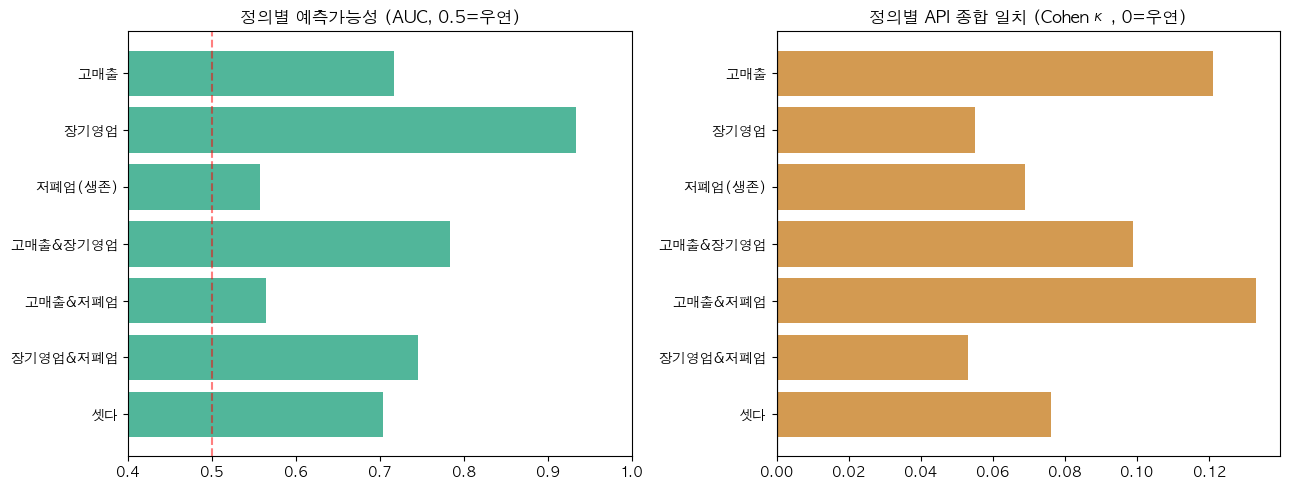

In [3]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].barh(R['정의'][::-1],R['예측AUC'][::-1],color='#3a8',alpha=.85); ax[0].axvline(0.5,color='r',ls='--',alpha=.5)
ax[0].set_title('정의별 예측가능성 (AUC, 0.5=우연)'); ax[0].set_xlim(0.4,1)
ax[1].barh(R['정의'][::-1],R['API종합κ'][::-1],color='#c83',alpha=.85); ax[1].axvline(0,color='k',lw=.8)
ax[1].set_title('정의별 API 종합 일치 (Cohen κ, 0=우연)')
plt.tight_layout(); plt.show()

## §25.2 결론 — 정의에 따라 결과가 크게 달라진다

**측정 결과(GroupKFold, 누설 차단):**
1. **저폐업(생존) 정의는 예측 불가(AUC≈0.56, 우연 수준)** — 어떤 조합으로 묶어도 폐업은 노이즈. (전 분석과 일관: 폐업 희소·노이즈.)
2. **매출 기반 정의는 예측 가능**(고매출 0.71, 고매출&장기영업 0.79).
3. **어떤 성공 정의도 창업기상 API 종합과 약하게만 일치**(κ 0.05~0.13) — 정의를 바꿔도 API 불일치는 해소되지 않는다.
   → 우리 데이터와 공단 지수는 측정 차원 자체가 다름(정의 문제 아님).
4. 장기영업 AUC가 높게 보이나(0.93), 이는 자치구 단위 장기영업 경향이 강해서로, 해석엔 주의(gu 효과).

**함의:**
- '성공'은 정의에 따라 모델 성능·의미가 달라지므로 **단일 정의로 단정 말고 정의를 명시·비교**해야 한다.
- **생존을 ML로 예측하는 정의는 어느 것도 작동 안 함**(노이즈) → 생존은 측정 지수(평균 영업기간, nb21/24)로 다루는 게 옳다.
- 매출 기반 정의가 가장 예측 가능하고 외부지표와도 (약하지만) 가장 정합 → 본 프로젝트의 매출 중심 접근을 지지.